# Order Book — definition & simulation

Building a LOB from scratch and generating a Hawkes-driven event stream.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from order_book import LimitOrderBook, Side, LOBGenerator

## 1. Basic mechanics

In [2]:
lob = LimitOrderBook(tick_size=0.01)

for i in range(1, 7):
    lob.submit_limit(Side.BID, 100 - i * 0.10, qty=8 + i * 2, timestamp=0.0)
    lob.submit_limit(Side.ASK, 100 + i * 0.10, qty=8 + i * 2, timestamp=0.0)

print(lob)
print(f'\nmid={lob.mid_price():.4f}  spread={lob.spread():.4f}')

── LOB ──────────────────────
  ASK   100.5000     18.00
  ASK   100.4000     16.00
  ASK   100.3000     14.00
  ASK   100.2000     12.00
  ASK   100.1000     10.00
  mid  100.0000  spread=0.2000
  BID    99.9000     10.00
  BID    99.8000     12.00
  BID    99.7000     14.00
  BID    99.6000     16.00
  BID    99.5000     18.00

mid=100.0000  spread=0.2000


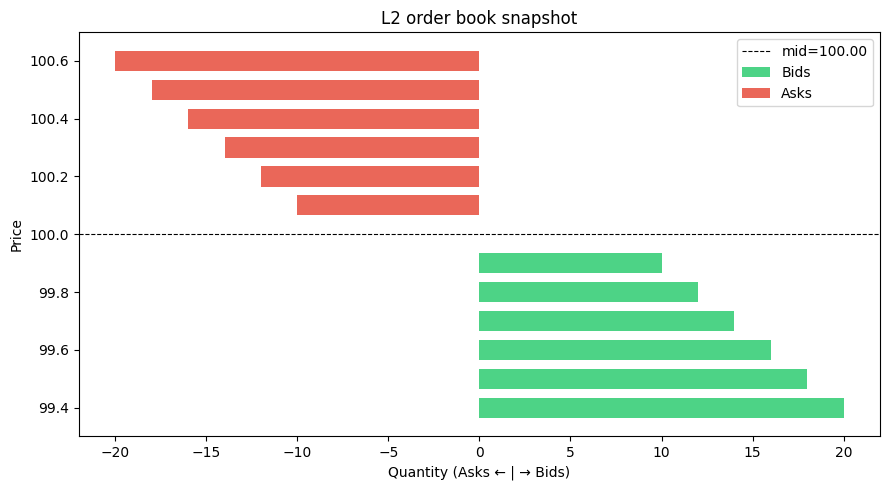

In [3]:
snap = lob.snapshot(depth=8)

fig, ax = plt.subplots(figsize=(9, 5))
bid_p, bid_q = zip(*snap['bids'])
ask_p, ask_q = zip(*snap['asks'])

ax.barh(bid_p,  bid_q,              height=0.07, color='#2ecc71', alpha=0.85, label='Bids')
ax.barh(ask_p, [-q for q in ask_q], height=0.07, color='#e74c3c', alpha=0.85, label='Asks')
ax.axhline(snap['mid'], color='black', lw=0.8, ls='--', label=f"mid={snap['mid']:.2f}")
ax.set_xlabel('Quantity (Asks ← | → Bids)')
ax.set_ylabel('Price')
ax.set_title('L2 order book snapshot')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Matching engine

In [4]:
oid, trades = lob.submit_market(Side.BID, qty=35.0, timestamp=1.0)
print(f'market buy 35 -> {len(trades)} fill(s)')
for t in trades:
    print(f'  {t.quantity:.1f} @ {t.price:.4f}')
print(f'new best ask: {lob.best_ask()}')

market buy 35 -> 3 fill(s)
  10.0 @ 100.1000
  12.0 @ 100.2000
  13.0 @ 100.3000
new best ask: 100.3


In [5]:
# aggressive limit crosses the spread and consumes multiple levels
lob2 = LimitOrderBook(tick_size=0.01)
lob2.submit_limit(Side.ASK, 100.00, qty=5.0,  timestamp=0.0)
lob2.submit_limit(Side.ASK, 100.05, qty=10.0, timestamp=0.1)
lob2.submit_limit(Side.ASK, 100.10, qty=8.0,  timestamp=0.2)

_, tr = lob2.submit_limit(Side.BID, 100.10, qty=18.0, timestamp=1.0)
print(f'aggressive limit buy 18 -> {len(tr)} fill(s)')
for t in tr:
    print(f'  {t.quantity:.1f} @ {t.price:.4f}')

aggressive limit buy 18 -> 3 fill(s)
  5.0 @ 100.0000
  10.0 @ 100.0500
  3.0 @ 100.1000


## 3. Hawkes-driven event stream

In [6]:
T_SIM = 1000.0

gen    = LOBGenerator(mid0=100.0, sigma_mid=0.015, seed=42)
events = gen.generate(T=T_SIM)

print(f'{len(events)} events over {T_SIM}s  ({len(events)/T_SIM:.1f} ev/s)')
counts = Counter(e.event_type for e in events)
for k in sorted(counts):
    print(f'  {k:<15} {counts[k]:6d}')

4774 events over 1000.0s  (4.8 ev/s)
  cancel_ask         327
  cancel_bid         311
  limit_ask         1551
  limit_bid         1555
  mkt_buy            499
  mkt_sell           531


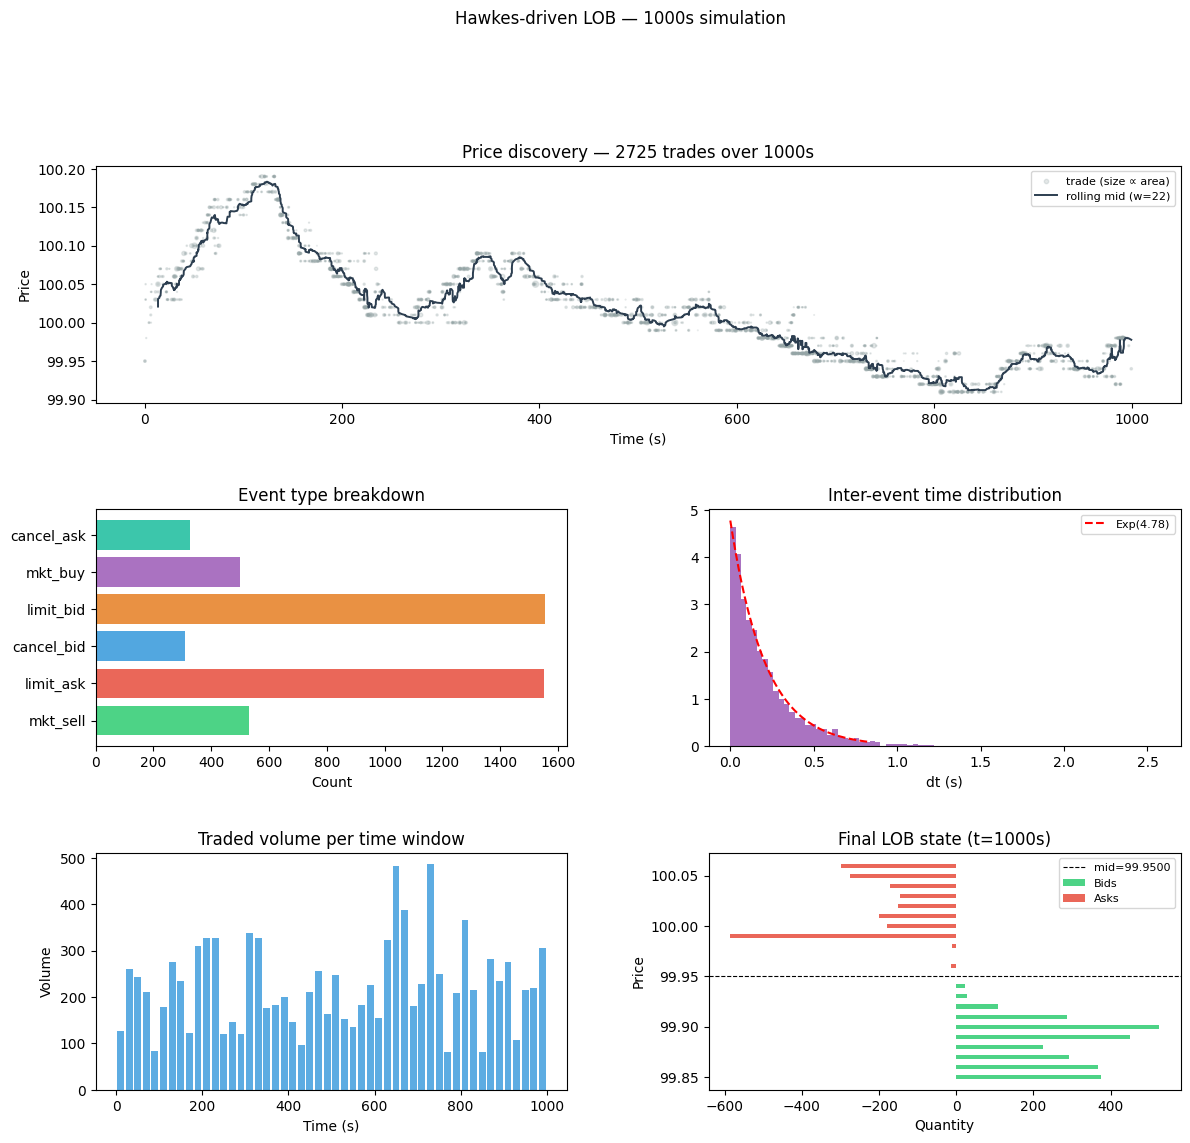

In [7]:
trade_times  = np.array([t.timestamp for e in events for t in e.trades])
trade_prices = np.array([t.price     for e in events for t in e.trades])
trade_sizes  = np.array([t.quantity  for e in events for t in e.trades])

# spread & volume over time (bin into 50 windows)
n_bins   = 50
bin_edges = np.linspace(0, T_SIM, n_bins + 1)
bin_mid   = 0.5 * (bin_edges[:-1] + bin_edges[1:])
vol_bins  = np.array([trade_sizes[(trade_times >= bin_edges[i]) & (trade_times < bin_edges[i+1])].sum()
                      for i in range(n_bins)])

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.30)

# --- price discovery ---
ax0 = fig.add_subplot(gs[0, :])
ax0.scatter(trade_times, trade_prices, s=trade_sizes / trade_sizes.max() * 20,
            alpha=0.25, color='#95a5a6', zorder=1, label='trade (size ∝ area)')
if len(trade_times) > 100:
    w   = max(1, len(trade_times) // 120)
    mid = np.convolve(trade_prices, np.ones(w)/w, mode='valid')
    ax0.plot(trade_times[w-1:], mid, color='#2c3e50', lw=1.4, zorder=2, label=f'rolling mid (w={w})')
ax0.set_xlabel('Time (s)')
ax0.set_ylabel('Price')
ax0.set_title(f'Price discovery — {len(trade_times)} trades over {T_SIM:.0f}s')
ax0.legend(fontsize=8)

# --- event type breakdown ---
ax1 = fig.add_subplot(gs[1, 0])
labels = list(counts.keys())
vals   = [counts[k] for k in labels]
cols   = ['#2ecc71','#e74c3c','#3498db','#e67e22','#9b59b6','#1abc9c']
ax1.barh(labels, vals, color=cols[:len(labels)], alpha=0.85)
ax1.set_xlabel('Count')
ax1.set_title('Event type breakdown')

# --- inter-event times ---
ax2 = fig.add_subplot(gs[1, 1])
dt_arr = np.diff(sorted([e.timestamp for e in events]))
ax2.hist(dt_arr, bins=80, color='#8e44ad', alpha=0.75, density=True)
xs  = np.linspace(0, np.percentile(dt_arr, 98), 300)
lam = 1.0 / dt_arr.mean()
ax2.plot(xs, lam * np.exp(-lam * xs), 'r--', lw=1.5, label=f'Exp({lam:.2f})')
ax2.set_title('Inter-event time distribution')
ax2.set_xlabel('dt (s)')
ax2.legend(fontsize=8)

# --- volume over time ---
ax3 = fig.add_subplot(gs[2, 0])
ax3.bar(bin_mid, vol_bins, width=(T_SIM / n_bins) * 0.8, color='#3498db', alpha=0.8)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Volume')
ax3.set_title('Traded volume per time window')

# --- final LOB snapshot ---
ax4 = fig.add_subplot(gs[2, 1])
snap_f = gen.lob.snapshot(depth=10)
if snap_f['bids'] and snap_f['asks']:
    bp, bq = zip(*snap_f['bids'])
    ap, aq = zip(*snap_f['asks'])
    ax4.barh(bp,  bq,              height=0.004, color='#2ecc71', alpha=0.85, label='Bids')
    ax4.barh(ap, [-q for q in aq], height=0.004, color='#e74c3c', alpha=0.85, label='Asks')
    ax4.axhline(snap_f['mid'], color='black', lw=0.8, ls='--', label=f"mid={snap_f['mid']:.4f}")
ax4.set_title(f'Final LOB state (t={T_SIM:.0f}s)')
ax4.set_xlabel('Quantity')
ax4.set_ylabel('Price')
ax4.legend(fontsize=8)

plt.suptitle(f'Hawkes-driven LOB — {T_SIM:.0f}s simulation', fontsize=12, y=1.01)
plt.show()

In [8]:
trade_sizes = [t.quantity for e in events for t in e.trades]
print(f'trades:       {len(trade_sizes)}')
print(f'avg size:     {np.mean(trade_sizes):.2f}')
print(f'total volume: {sum(trade_sizes):.0f}')
print(f'returns std:  {np.std(np.diff(trade_prices)):.5f}')

trades:       2725
avg size:     4.12
total volume: 11214
returns std:  0.01435


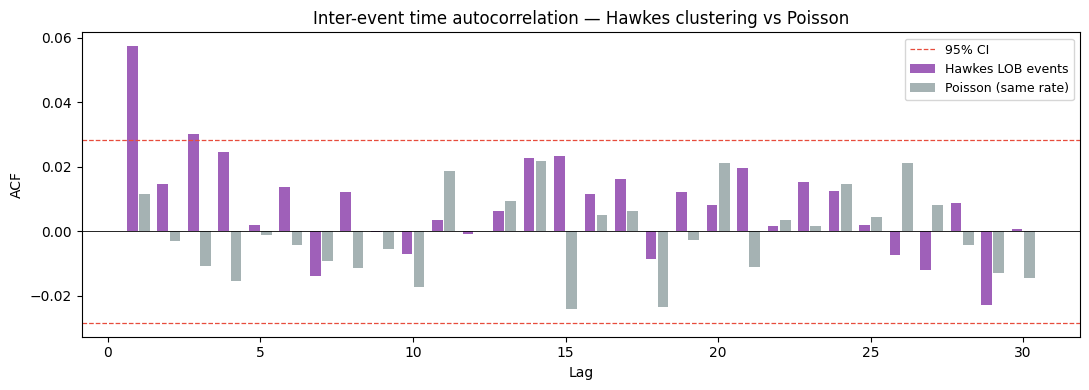

In [9]:
# inter-event times should show positive autocorrelation if Hawkes (events cluster)
# vs Poisson which is memoryless -> no autocorrelation

def empirical_acf(x, nlags=30):
    x = np.asarray(x, dtype=float) - np.mean(x)
    acov = np.correlate(x, x, mode='full')[len(x)-1:]
    return acov[:nlags+1] / acov[0]

all_times = sorted(e.timestamp for e in events)
dt_lob    = np.diff(all_times)
dt_pois   = np.random.default_rng(99).exponential(dt_lob.mean(), size=len(dt_lob))

lags  = np.arange(1, 31)
acf_h = empirical_acf(dt_lob)[1:]
acf_p = empirical_acf(dt_pois)[1:]
ci    = 1.96 / np.sqrt(len(dt_lob))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(lags - 0.2, acf_h, width=0.35, alpha=0.85, color='#8e44ad', label='Hawkes LOB events')
ax.bar(lags + 0.2, acf_p, width=0.35, alpha=0.85, color='#95a5a6', label='Poisson (same rate)')
ax.axhline( ci, color='#e74c3c', lw=0.9, ls='--', label='95% CI')
ax.axhline(-ci, color='#e74c3c', lw=0.9, ls='--')
ax.axhline(0,   color='black',   lw=0.6)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_title('Inter-event time autocorrelation — Hawkes clustering vs Poisson')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()